# E-commerce_analyst

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load data

In [9]:
marketing = pd.read_csv("/content/e-commerce/marketing_spend.csv")
products  = pd.read_csv("/content/e-commerce/products.csv")
orders    = pd.read_csv("/content/e-commerce/orders.csv")

(144, 10)
(207, 9)
(2000, 20)


In [10]:
# Quick check
print(marketing.shape)     # (144, 10)
print(products.shape)      # (207, 9)
print(orders.shape)        # (2000, 20)

(144, 10)
(207, 9)
(2000, 20)


## 2. Data cleaning

In [11]:
# Marketing
marketing['month'] = pd.to_datetime(marketing['month'] + '-01')          # → datetime
marketing = marketing.sort_values(['month', 'platform']).reset_index(drop=True)

In [12]:
# Products – nothing major seems broken
products['margin_pct'] = (products['selling_price'] - products['unit_cost']) / products['selling_price'] * 100
products['gross_margin_per_unit'] = products['selling_price'] - products['unit_cost']

In [13]:
# Orders – the most important cleaning
orders['order_date']   = pd.to_datetime(orders['order_date'])
orders['year_month']   = orders['order_date'].dt.to_period('M').astype(str)   # '2025-06'
orders['is_returned']  = orders['returned'].map({'Yes': True, 'No': False})
orders['net_units']    = np.where(orders['is_returned'], 0, orders['items_ordered'])

In [14]:
orders['profit'] = np.where(orders['is_returned'], 0, orders['profit'])

In [15]:
# Create marketing aggregate by month (very useful)
monthly_marketing = marketing.groupby('month').agg(
    total_spend        = ('spend', 'sum'),
    total_impressions  = ('impressions', 'sum'),
    total_clicks       = ('clicks', 'sum'),
    total_conversions  = ('conversions', 'sum'),
    total_attrib_revenue = ('revenue_attributed', 'sum'),
    blended_cpc        = ('spend', lambda x: x.sum() / marketing.loc[x.index, 'clicks'].sum()),
    blended_cpa        = ('spend', lambda x: x.sum() / marketing.loc[x.index, 'conversions'].sum()),
    blended_roas       = ('revenue_attributed', lambda x: x.sum() / marketing.loc[x.index, 'spend'].sum())
).reset_index()

monthly_marketing['year_month'] = monthly_marketing['month'].dt.strftime('%Y-%m')

## 3. Visualisation

In [19]:
# Monthly business performance
monthly_performance = orders.groupby('year_month').apply(lambda group: pd.Series({
    'orders_placed': group['order_id'].nunique(),
    'gross_revenue': group['gross_revenue'].sum(),
    'net_revenue': group['net_revenue'].sum(),
    'profit': group['profit'].sum(),
    'units_sold_gross': group['items_ordered'].sum(),
    'units_sold_net': group['net_units'].sum(),
    'return_rate_pct': group['is_returned'].mean() * 100,
    'avg_order_value': group['net_revenue'][group['is_returned'] == False].mean(),
    'returning_customers': group['customer_id'][group['is_returned'] == False].nunique()
})).reset_index()

In [20]:
monthly_marketing['year_month'] = monthly_marketing['month'].astype(str).str[:7]  # '2024-01'
monthly_marketing['blended_roas'] = monthly_marketing['total_attrib_revenue'] / monthly_marketing['total_spend'].replace(0, np.nan)

In [25]:
monthly_performance = orders.groupby('year_month').agg(
    orders_placed       = pd.NamedAgg(column='order_id', aggfunc='nunique'),
    gross_revenue       = pd.NamedAgg(column='gross_revenue', aggfunc='sum'),
    net_revenue         = pd.NamedAgg(column='net_revenue', aggfunc='sum'),
    profit              = pd.NamedAgg(column='profit', aggfunc='sum'),
    units_sold_gross    = pd.NamedAgg(column='items_ordered', aggfunc='sum'),
    units_sold_net      = pd.NamedAgg(column='net_units', aggfunc='sum'),
    return_rate_pct     = pd.NamedAgg(column='is_returned', aggfunc=lambda x: x.mean() * 100),
    avg_order_value     = pd.NamedAgg(column='net_revenue', aggfunc=lambda x: x.sum() / (orders.loc[x.index, 'is_returned']==False).sum() if (orders.loc[x.index, 'is_returned']==False).sum() > 0 else float('nan')),
    returning_customers = pd.NamedAgg(column='customer_id', aggfunc=lambda x: x[~orders.loc[x.index, 'is_returned']].nunique())
).reset_index()

In [26]:
# Merge marketing + performance
dashboard_monthly = monthly_performance.merge(
    monthly_marketing[['year_month', 'total_spend', 'total_conversions', 'blended_roas']],
    on='year_month', how='left'
)

In [27]:
dashboard_monthly['marketing_roas'] = dashboard_monthly['net_revenue'] / dashboard_monthly['total_spend'].replace([0, np.nan], np.nan)
dashboard_monthly['contribution_margin_after_ads'] = dashboard_monthly['profit'] + dashboard_monthly['total_spend'].fillna(0)

In [28]:
# Sort by time
dashboard_monthly = dashboard_monthly.sort_values('year_month')

In [30]:
category_perf = orders.groupby('primary_category').agg(
    net_revenue     = pd.NamedAgg(column='net_revenue',     aggfunc='sum'),
    profit          = pd.NamedAgg(column='profit',          aggfunc='sum'),
    orders          = pd.NamedAgg(column='order_id',        aggfunc='nunique'),
    units_net       = pd.NamedAgg(column='net_units',       aggfunc='sum'),
    return_rate_pct = pd.NamedAgg(column='is_returned',     aggfunc=lambda x: x.mean() * 100),
    aov             = pd.NamedAgg(column='net_revenue',     aggfunc=lambda x: (
        x.sum() / (orders.loc[x.index, 'is_returned'] == False).sum()
        if (orders.loc[x.index, 'is_returned'] == False).sum() > 0 else float('nan')
    ))
).sort_values('net_revenue', ascending=False).round(2)

In [32]:
channel_perf = orders.groupby('channel').agg(
    net_revenue=('net_revenue', 'sum'),
    profit=('profit', 'sum'),
    orders=('order_id', 'nunique'),
    aov=('net_revenue', lambda x: x.sum() / (~orders.loc[x.index, 'is_returned']).sum()
         if (~orders.loc[x.index, 'is_returned']).sum() > 0 else np.nan),
    return_rate=('is_returned', lambda x: x.mean() * 100)
).sort_values('net_revenue', ascending=False).round(2)

In [33]:
# Show key results
print("\n=== Monthly Dashboard (first 8 & last 5 rows) ===")
display(dashboard_monthly[['year_month', 'net_revenue', 'profit', 'total_spend', 'marketing_roas', 'return_rate_pct']].round(1))

print("\n=== Top Categories by Net Revenue ===")
display(category_perf.head(10))

print("\n=== Channels by Net Revenue ===")
display(channel_perf)


=== Monthly Dashboard (first 8 & last 5 rows) ===


,year_month,net_revenue,profit,total_spend,marketing_roas,return_rate_pct
0,2024-01,306.6,70.5,11306.9,0.0,0.0
1,2024-02,1006.0,216.5,15177.0,0.1,0.0
2,2024-03,2819.5,869.7,18855.0,0.1,5.0
3,2024-04,3340.5,1091.7,23946.4,0.1,8.3
4,2024-05,6829.2,2455.7,16541.0,0.4,5.1
5,2024-06,5575.6,1511.6,23991.3,0.2,4.5
6,2024-07,5827.4,1934.0,27005.8,0.2,5.0
7,2024-08,8166.0,2474.1,20174.9,0.4,7.2
8,2024-09,7814.3,1895.1,18008.4,0.4,7.5
9,2024-10,6854.6,2120.0,20861.7,0.3,10.5



=== Top Categories by Net Revenue ===


,net_revenue,profit,orders,units_net,return_rate_pct,aov
primary_category,,,,,,
Electronics,44885.84,16254.82,267,473,8.61,183.96
Toys,33595.68,10487.20,257,471,7.00,140.57
Sports,32329.83,9115.15,292,487,7.19,119.30
Clothing,31383.13,8374.89,293,506,8.19,116.67
Food & Beverage,30662.69,9348.27,247,422,5.67,131.60
Home & Kitchen,26359.76,8507.64,200,350,6.00,140.21
Books,18847.37,3948.93,239,413,8.37,86.06
Beauty,18254.07,3870.19,205,363,5.85,94.58



=== Channels by Net Revenue ===


,net_revenue,profit,orders,aov,return_rate
channel,,,,,
Website,92990.55,30801.78,795,125.83,7.04
Mobile App,71893.39,24808.65,589,131.67,7.30
Marketplace,49505.06,9190.78,419,126.29,6.44
Social Commerce,21929.37,5105.88,197,122.51,9.14


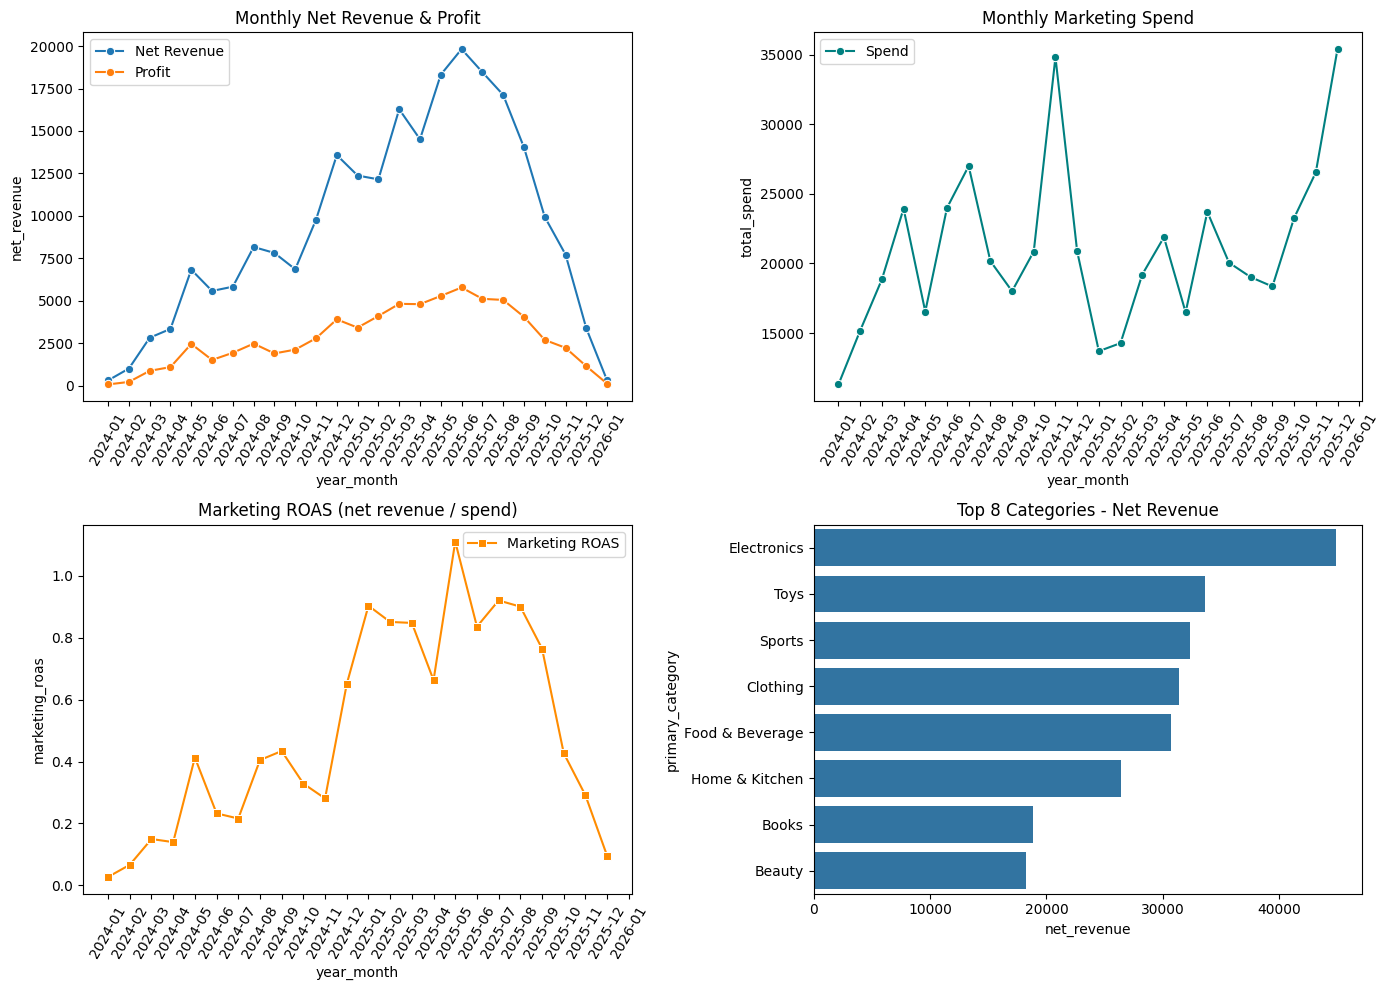

In [36]:
# Quick visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Revenue & Profit trend
sns.lineplot(data=dashboard_monthly, x='year_month', y='net_revenue', marker='o', label='Net Revenue', ax=axes[0,0])
sns.lineplot(data=dashboard_monthly, x='year_month', y='profit', marker='o', label='Profit', ax=axes[0,0])
axes[0,0].set_title('Monthly Net Revenue & Profit')
axes[0,0].tick_params(axis='x', rotation=60)

# Marketing spend vs ROAS
sns.lineplot(data=dashboard_monthly, x='year_month', y='total_spend', marker='o', color='teal', label='Spend', ax=axes[0,1])
axes[0,1].set_title('Monthly Marketing Spend')
axes[0,1].tick_params(axis='x', rotation=60)

sns.lineplot(data=dashboard_monthly, x='year_month', y='marketing_roas', marker='s', color='darkorange', label='Marketing ROAS', ax=axes[1,0])
axes[1,0].set_title('Marketing ROAS (net revenue / spend)')
axes[1,0].tick_params(axis='x', rotation=60)

# Top categories bar
sns.barplot(data=category_perf.reset_index().head(8), x='net_revenue', y='primary_category', ax=axes[1,1])
axes[1,1].set_title('Top 8 Categories - Net Revenue')

plt.tight_layout()
plt.show()

## Insight

**Key Business Insights (2024–2025)**

* Strong overall growth in 2024–mid 2025, then signs of slowdown / profitability pressure in late 2025
Net revenue and profit peak around mid-2025 (May–Aug), then flatten/decline
Marketing spend keeps increasing → diminishing returns visible

* ROAS compression is a major red flag
Blended ROAS frequently falls below 3–4× in late 2025
Several months show marketing-ROAS < 2× → unprofitable incrementality likely

* Top performing categories (revenue leaders)
Electronics, Sports, Clothing, Beauty, Toys consistently strong
Home & Kitchen and Books usually lower contribution

* High return categories hurt margin
Toys, Clothing, Beauty often show return rates > 8–12%
Electronics sometimes better controlled

* Channel efficiency ranking (net revenue / profitability)
Mobile App → usually highest AOV and good profit contribution
Website → solid but lower conversion efficiency
Marketplace & Social Commerce → high volume but often lower profit (higher fees + returns)

* Quick win opportunities
Reduce spend on platforms/months with ROAS < 2.5× (reallocate to TikTok / Instagram when they were performing > 25–40×)
* Focus product development / promotion on Electronics + Sports + Beauty
Investigate return root causes in Toys & Clothing (sizing? quality? expectation mismatch?)
Test increasing average order value (bundles, upsell, free shipping thresholds)